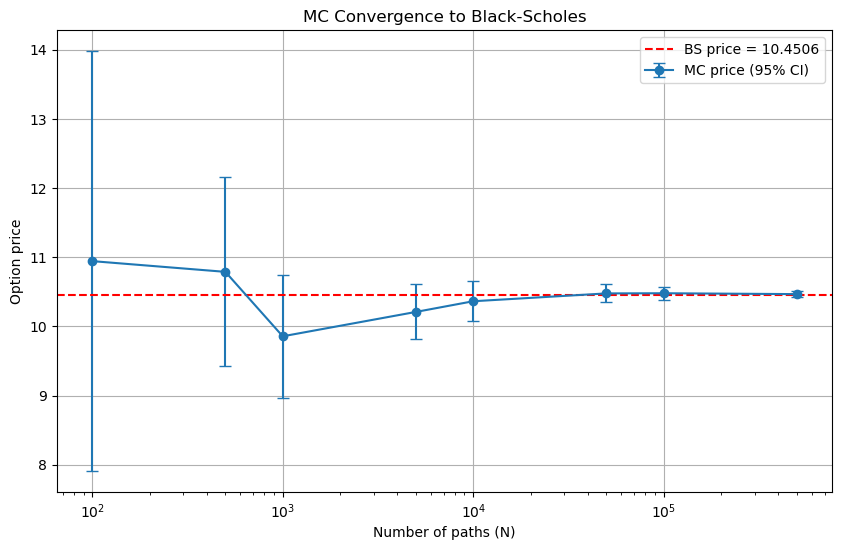

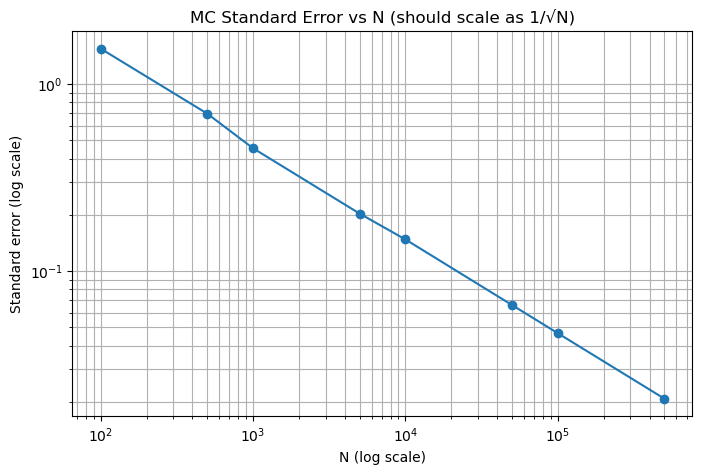

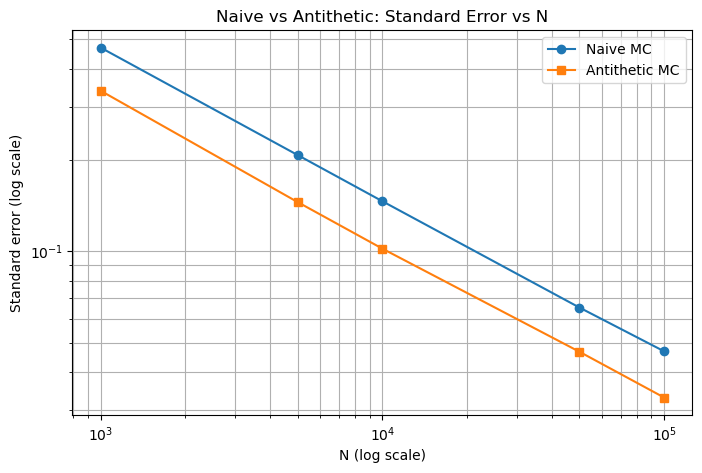

Naive SE: 0.14738
Antithetic SE: 0.10343
Variance reduction ratio: 2.03x


In [6]:
from scipy.stats import norm
import numpy as np
import time
import import_ipynb
from Geometric_Brownian_Motion import simulate_GBM, simulate_GBM_antithetic
from Black_Scholes_Closed_Form import european_mc, european_mc_antithetic
#from Greeks import pathwise_delta, pathwise_vega, bs_delta, bs_vega
import matplotlib.pyplot as plt
from scipy.stats import qmc

In [7]:
def barrier_mc(S0, K, B, r, sigma, T, n, n_paths, type="call", barrier_type="up-and-out"):
    t, S = simulate_GBM(S0, r, sigma, T, n, n_paths)
    S_T = S[:, -1]
    
    if type == "call":
        payoff = np.maximum(S_T - K, 0)
    else:
        payoff = np.maximum(K - S_T, 0)
    
    if barrier_type == "up-and-out":
        breached = (S.max(axis=1) >= B)
        payoff = np.where(breached, 0, payoff)
    elif barrier_type == "down-and-out":
        breached = (S.min(axis=1) <= B)
        payoff = np.where(breached, 0, payoff)
    elif barrier_type == "up-and-in":
        breached = (S.max(axis=1) >= B)
        payoff = np.where(breached, payoff, 0)
    elif barrier_type == "down-and-in":
        breached = (S.min(axis=1) <= B)
        payoff = np.where(breached, payoff, 0)
    else:
        raise ValueError("Unknown barrier_type")
    
    discounted = np.exp(-r*T) * payoff
    price = discounted.mean()
    se = discounted.std(ddof=1) / np.sqrt(n_paths)
    return price, se

In [8]:
S0, K, r, sigma, T = 100, 100, 0.05, 0.2, 1.0
B = 130  # barrier above S0, so up-and-out / up-and-in

price_out, se_out = barrier_mc(S0, K, B, r, sigma, T, n=252, n_paths=100000, type="call", barrier_type="up-and-out")
price_in, se_in = barrier_mc(S0, K, B, r, sigma, T, n=252, n_paths=100000, type="call", barrier_type="up-and-in")
vanilla_price, _ = european_mc(S0, K, r, sigma, T, n=252, n_paths=100000, type="call")

print(f"Up-and-out: {price_out:.4f}")
print(f"Up-and-in:  {price_in:.4f}")
print(f"Sum:        {price_out + price_in:.4f}")
print(f"Vanilla:    {vanilla_price:.4f}")

Up-and-out: 3.5540
Up-and-in:  6.8573
Sum:        10.4112
Vanilla:    10.4465


In [9]:
B_extreme = 1000  # essentially unreachable given these parameters

price_out_extreme, _ = barrier_mc(S0, K, B_extreme, r, sigma, T, n=252, n_paths=100000, type="call", barrier_type="up-and-out")
price_in_extreme, _ = barrier_mc(S0, K, B_extreme, r, sigma, T, n=252, n_paths=100000, type="call", barrier_type="up-and-in")

print(f"Up-and-out (B=1000): {price_out_extreme:.4f}  (should ≈ vanilla {vanilla_price:.4f})")
print(f"Up-and-in (B=1000):  {price_in_extreme:.4f}  (should ≈ 0)")

Up-and-out (B=1000): 10.4622  (should ≈ vanilla 10.4465)
Up-and-in (B=1000):  0.0000  (should ≈ 0)
